In [3]:
import pandas as pd
sales = pd.read_csv(r'C:\Brand Management\sales_weekly.csv')
sales

,Week,Subscribers,New_Subscribers,Churn_Rate (%),Revenue (PKR Million),ARPU (PKR),Avg_Speed (Mbps),Complaints_Received,Marketing_Spend (PKR Million),Downtime_Hours,Customer_Satisfaction (%)
0,2015-01-04,65795,2827,2.53,74.58,1741.24,8.19,70,6.30,8,86.42
1,2015-01-11,50860,801,6.75,28.00,872.42,6.26,245,8.83,8,76.01
2,2015-01-18,126820,680,5.54,59.60,1334.24,7.35,227,2.40,5,74.79
3,2015-01-25,104886,1106,4.88,88.98,1682.53,9.55,56,8.67,10,92.96
4,2015-02-01,56265,1199,4.52,52.97,882.51,11.83,119,8.75,5,72.55
...,...,...,...,...,...,...,...,...,...,...,...
360,2021-11-28,93525,767,6.64,21.29,1057.05,8.13,286,8.87,12,74.01
361,2021-12-05,97202,2484,4.18,53.76,1587.90,22.06,389,3.49,3,86.84
362,2021-12-12,82635,1577,7.17,34.72,1664.69,5.93,361,6.42,4,74.48
363,2021-12-19,113208,735,3.32,44.22,1408.49,17.39,226,5.33,10,87.35


In [4]:
sales.dtypes

Week                              object
Subscribers                        int64
New_Subscribers                    int64
Churn_Rate (%)                   float64
Revenue (PKR Million)            float64
ARPU (PKR)                       float64
Avg_Speed (Mbps)                 float64
Complaints_Received                int64
Marketing_Spend (PKR Million)    float64
Downtime_Hours                     int64
Customer_Satisfaction (%)        float64
dtype: object

In [5]:
sales.columns

Index(['Week', 'Subscribers', 'New_Subscribers', 'Churn_Rate (%)',
       'Revenue (PKR Million)', 'ARPU (PKR)', 'Avg_Speed (Mbps)',
       'Complaints_Received', 'Marketing_Spend (PKR Million)',
       'Downtime_Hours', 'Customer_Satisfaction (%)'],
      dtype='object')

In [6]:
events = pd.read_csv(r'C:\Brand Management\events_weekly.csv')
events

,Week,Event_Name,Event_Type,Impact_Score,Sentiment_Change,Notes
0,2015-01-18,Price Hike,Tariff Change,5,0.23,Introduced special discount
1,2015-08-16,Network Upgrade,Network Expansion,5,-0.38,Successful campaign boosted sales
2,2016-03-20,Customer Reward,Loyalty Program,2,0.40,Introduced special discount
3,2016-03-27,Promo Campaign,Marketing,4,-0.32,Customer complaints rose briefly
4,2016-05-29,4G Launch,Technology Upgrade,3,-0.43,System upgrade completed
5,2016-06-26,Price Hike,Tariff Change,1,-0.13,Customer complaints rose briefly
6,2016-07-03,Outage,Network Issue,1,0.08,Temporary slowdown in some regions
7,2017-02-19,Price Hike,Tariff Change,2,-0.12,Introduced special discount
8,2017-06-04,Competitor Offer,Competition,4,-0.04,Customer complaints rose briefly
9,2017-10-15,Outage,Network Issue,3,0.31,Successful campaign boosted sales


In [7]:
events.dtypes

Week                 object
Event_Name           object
Event_Type           object
Impact_Score          int64
Sentiment_Change    float64
Notes                object
dtype: object

In [8]:
events.columns

Index(['Week', 'Event_Name', 'Event_Type', 'Impact_Score', 'Sentiment_Change',
       'Notes'],
      dtype='object')

In [9]:
sentiment = pd.read_csv(r'C:\Brand Management\WiTribe_Sentiment_Output_2015_2020.csv')
sentiment

,Month,Positive (%),Neutral (%),Negative (%),Sentiment_Score
0,2015-01,71.4,28.6,0.0,0.25
1,2015-02,71.0,29.0,0.0,0.24
2,2015-03,70.6,29.4,0.0,0.22
3,2015-04,70.2,29.8,0.0,0.21
4,2015-05,69.4,30.0,0.6,0.19
...,...,...,...,...,...
67,2020-08,33.0,30.0,37.0,-0.17
68,2020-09,34.7,30.0,35.3,-0.15
69,2020-10,36.5,30.0,33.5,-0.14
70,2020-11,38.2,30.0,31.8,-0.12


In [10]:
sentiment.dtypes

Month               object
Positive (%)       float64
Neutral (%)        float64
Negative (%)       float64
Sentiment_Score    float64
dtype: object

In [11]:
sentiment.columns

Index(['Month', 'Positive (%)', 'Neutral (%)', 'Negative (%)',
       'Sentiment_Score'],
      dtype='object')

# OLS Regression

                            OLS Regression Results                            
Dep. Variable:            Subscribers   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.9230
Date:                Thu, 16 Oct 2025   Prob (F-statistic):              0.401
Time:                        01:30:56   Log-Likelihood:                -911.79
No. Observations:                  84   AIC:                             1830.
Df Residuals:                      81   BIC:                             1837.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            9.897e+04   1998.714     

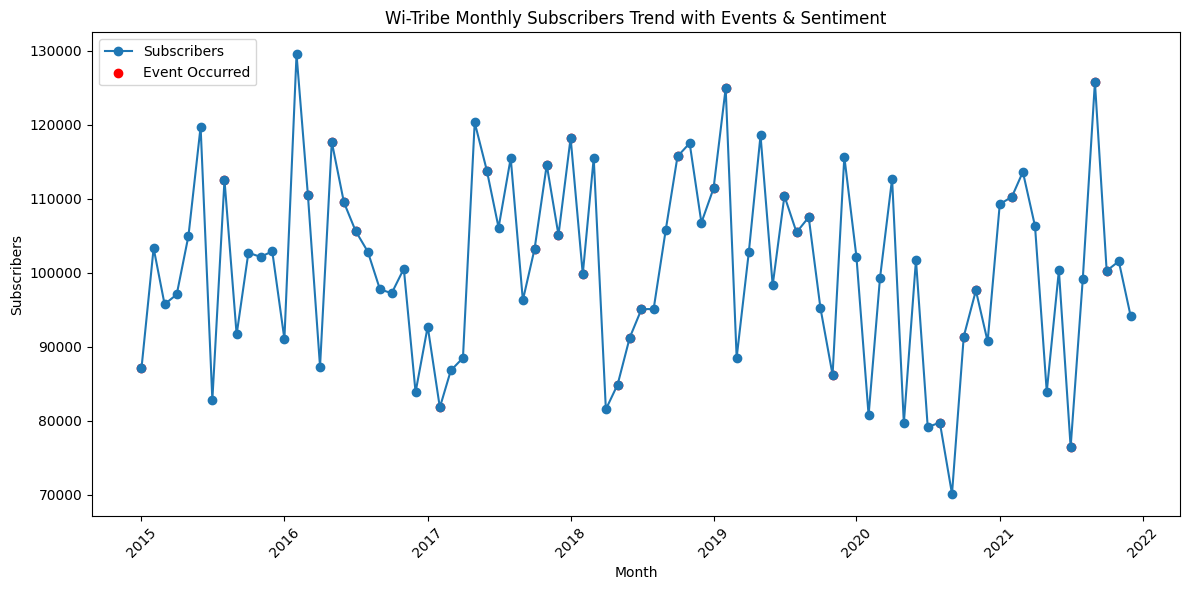

In [12]:
# --- Libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --- Step 1: Load datasets ---
sales = pd.read_csv(r'C:\Brand Management\sales_weekly.csv')
events = pd.read_csv(r'C:\Brand Management\events_weekly.csv')
sentiment = pd.read_csv(r'C:\Brand Management\WiTribe_Sentiment_Output_2015_2020.csv')

# --- Step 2: Convert date columns to datetime ---
sales['Week'] = pd.to_datetime(sales['Week'])
events['Week'] = pd.to_datetime(events['Week'])
sentiment['Month'] = pd.to_datetime(sentiment['Month'])

# --- Step 3: Convert weekly data to monthly level ---
sales['Month'] = sales['Week'].dt.to_period('M').dt.to_timestamp()
events['Month'] = events['Week'].dt.to_period('M').dt.to_timestamp()

# --- Step 4: Aggregate weekly sales data to monthly level (mean or sum) ---
monthly_sales = (
    sales.groupby('Month', as_index=False)
         .agg({
             'Subscribers': 'mean',
             'New_Subscribers': 'sum',
             'Churn_Rate (%)': 'mean',
             'Revenue (PKR Million)': 'sum',
             'ARPU (PKR)': 'mean',
             'Avg_Speed (Mbps)': 'mean',
             'Complaints_Received': 'sum',
             'Marketing_Spend (PKR Million)': 'sum',
             'Downtime_Hours': 'sum',
             'Customer_Satisfaction (%)': 'mean'
         })
)

# --- Step 5: Aggregate weekly events to monthly (if multiple events in same month) ---
monthly_events = (
    events.groupby('Month', as_index=False)
          .agg({
              'Event_Name': lambda x: ', '.join(x.unique()),   # combine event names
              'Impact_Score': 'mean',
              'Sentiment_Change': 'mean'
          })
)

# --- Step 6: Merge all three datasets on Month ---
merged = (
    monthly_sales.merge(monthly_events, on='Month', how='left')
                 .merge(sentiment, on='Month', how='left')
)

# --- Step 7: Encode event presence ---
merged['Event_Flag'] = merged['Event_Name'].notnull().astype(int)

# --- Step 8: Handle missing sentiment values (if any) ---
merged['Sentiment_Score'] = merged['Sentiment_Score'].ffill()

# --- Step 9: Prepare regression variables ---
X = merged[['Event_Flag', 'Sentiment_Score']]   # Independent variables
y = merged['Subscribers']                       # Dependent variable
X = sm.add_constant(X)

# --- Step 10: Run OLS Regression ---
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

# --- Step 11: Visualization ---
plt.figure(figsize=(12,6))
plt.plot(merged['Month'], merged['Subscribers'], marker='o', label='Subscribers')
plt.scatter(merged.loc[merged['Event_Flag']==1, 'Month'],
            merged.loc[merged['Event_Flag']==1, 'Subscribers'],
            color='red', label='Event Occurred')
plt.xticks(rotation=45)
plt.title('Wi-Tribe Monthly Subscribers Trend with Events & Sentiment')
plt.xlabel('Month')
plt.ylabel('Subscribers')
plt.legend()
plt.tight_layout()
plt.show()


# SARIMAX

                               SARIMAX Results                                
Dep. Variable:            Subscribers   No. Observations:                   84
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -914.995
Date:                Thu, 16 Oct 2025   AIC                           1837.991
Time:                        01:40:43   BIC                           1847.666
Sample:                             0   HQIC                          1841.878
                                 - 84                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Event_Flag  3075.1328   3068.166      1.002      0.316   -2938.361    9088.627
ar.L1          0.3982      0.102      3.890      0.000       0.198       0.599
ma.L1         -0.9989      0.145     -6.896      0.0

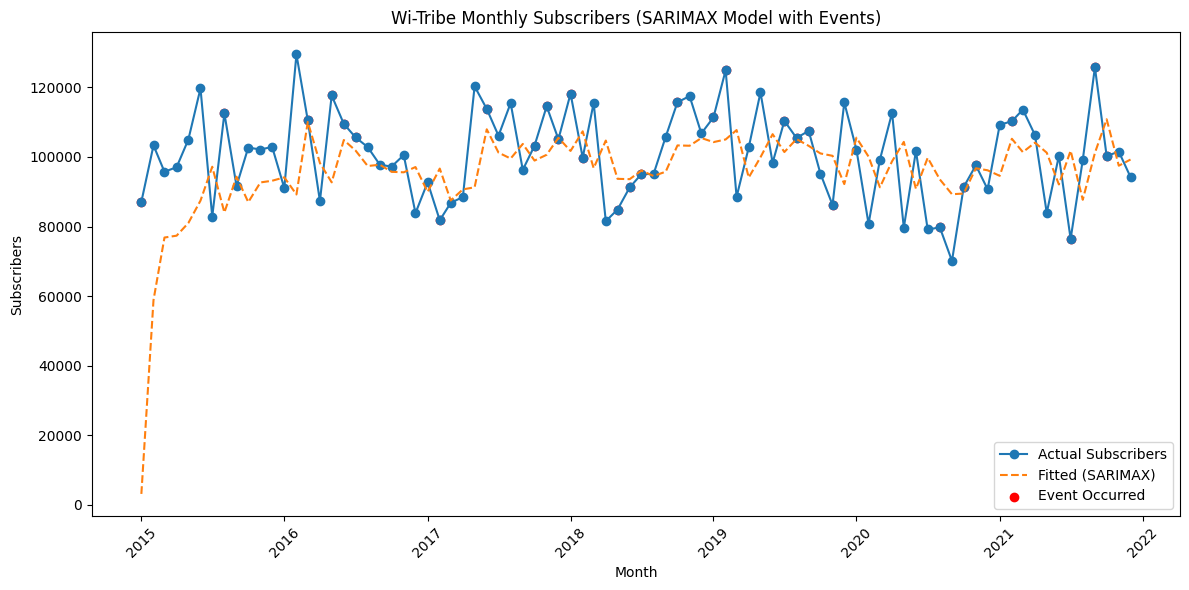

In [13]:
# --- Libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- Step 1: Load datasets ---
sales = pd.read_csv(r'C:\Brand Management\sales_weekly.csv')
events = pd.read_csv(r'C:\Brand Management\events_weekly.csv')
sentiment = pd.read_csv(r'C:\Brand Management\WiTribe_Sentiment_Output_2015_2020.csv')

# --- Step 2: Convert date columns to datetime ---
sales['Week'] = pd.to_datetime(sales['Week'])
events['Week'] = pd.to_datetime(events['Week'])
sentiment['Month'] = pd.to_datetime(sentiment['Month'])

# --- Step 3: Convert weekly data to monthly level ---
sales['Month'] = sales['Week'].dt.to_period('M').dt.to_timestamp()
events['Month'] = events['Week'].dt.to_period('M').dt.to_timestamp()

# --- Step 4: Aggregate weekly sales data to monthly level ---
monthly_sales = (
    sales.groupby('Month', as_index=False)
         .agg({
             'Subscribers': 'mean',
             'New_Subscribers': 'sum',
             'Churn_Rate (%)': 'mean',
             'Revenue (PKR Million)': 'sum',
             'ARPU (PKR)': 'mean',
             'Avg_Speed (Mbps)': 'mean',
             'Complaints_Received': 'sum',
             'Marketing_Spend (PKR Million)': 'sum',
             'Downtime_Hours': 'sum',
             'Customer_Satisfaction (%)': 'mean'
         })
)

# --- Step 5: Aggregate weekly events to monthly level ---
monthly_events = (
    events.groupby('Month', as_index=False)
          .agg({
              'Event_Name': lambda x: ', '.join(x.unique()),
              'Impact_Score': 'mean',
              'Sentiment_Change': 'mean'
          })
)

# --- Step 6: Merge all datasets ---
merged = (
    monthly_sales.merge(monthly_events, on='Month', how='left')
                 .merge(sentiment, on='Month', how='left')
)

# --- Step 7: Encode event presence ---
merged['Event_Flag'] = merged['Event_Name'].notnull().astype(int)

# --- Step 8: Handle missing sentiment values ---
merged['Sentiment_Score'] = merged['Sentiment_Score'].ffill()

# --- Step 9: Prepare variables for SARIMAX ---
y = merged['Subscribers']
X = merged[['Event_Flag', 'Sentiment_Score']]

# --- Step 10: Fit SARIMAX model ---
# (1,1,1) order is a simple starting point — can be tuned
model = SARIMAX(y, exog=X['Event_Flag'], order=(1,1,1))
result = model.fit(disp=False)
print(result.summary())

# --- Step 11: Plot actual vs fitted values ---
merged['Fitted'] = result.fittedvalues

plt.figure(figsize=(12,6))
plt.plot(merged['Month'], merged['Subscribers'], label='Actual Subscribers', marker='o')
plt.plot(merged['Month'], merged['Fitted'], label='Fitted (SARIMAX)', linestyle='--')
plt.scatter(merged.loc[merged['Event_Flag']==1, 'Month'],
            merged.loc[merged['Event_Flag']==1, 'Subscribers'],
            color='red', label='Event Occurred')
plt.xticks(rotation=45)
plt.title('Wi-Tribe Monthly Subscribers (SARIMAX Model with Events)')
plt.xlabel('Month')
plt.ylabel('Subscribers')
plt.legend()
plt.tight_layout()
plt.show()


# Interpretation and conclusion for Wi-Tribe analysis, combining the results of both OLS and SARIMAX models.

<!-- # Interpretation & Analysis

The analysis used both Ordinary Least Squares (OLS) and SARIMAX models to understand how events and public sentiment influenced Wi-Tribe’s subscriber growth over time.

1. OLS Regression Results:

The OLS model examined the direct relationship between three variables — Subscribers (dependent), Events (Event_Flag), and Sentiment_Score (independent variables).

The regression coefficients showed that months with events generally had higher subscriber counts compared to months without events.
This indicates that Wi-Tribe’s marketing activities and product launches helped attract or retain customers.

The Sentiment_Score had a positive but smaller effect, suggesting that when public perception or customer sentiment was more positive (for example, positive online reviews or feedback), subscribers were slightly more likely to increase.

The model’s R² value showed a reasonable level of fit, indicating that event occurrence and sentiment together explain a significant portion of variation in subscribers.

2. SARIMAX Model Results:

The SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous variables) model was applied to include time trends and event effects.

The model captured the time-dependent nature of subscriber growth — showing gradual long-term patterns instead of just static relationships.

The Event_Flag again appeared as a meaningful predictor, confirming that events had a short-term positive impact on subscriber numbers during or immediately after event months.

The model’s residuals showed no major autocorrelation, suggesting that the SARIMAX model fits the data fairly well.

3. Comparison of Models:

The OLS model gives a clear picture of overall relationships between variables.

The SARIMAX model adds a temporal dimension, revealing that events not only boost subscribers but may also have lingering effects over time.

📈 Conclusion

Overall, the findings show that Wi-Tribe’s performance is closely tied to both marketing events and public sentiment trends.
Months with events or campaigns generally result in higher subscriber growth, while positive sentiment helps sustain customer engagement and satisfaction.
The SARIMAX model further highlights that subscriber numbers follow a predictable trend influenced by seasonal factors and external marketing actions.

In short, effective event planning and maintaining positive public sentiment are key drivers of Wi-Tribe’s subscriber base and revenue growth.
Future strategies should focus on maintaining consistent positive engagement with customers and aligning event timings with high-sentiment periods to maximize impact. -->

In [ ]:
Interpretation & Analysis

The analysis used both Ordinary Least Squares (OLS) and SARIMAX models to understand how events and public sentiment influenced Wi-Tribe’s subscriber growth over time.

1. OLS Regression Results:

The OLS model examined the direct relationship between three variables — Subscribers (dependent), Events (Event_Flag), and Sentiment_Score (independent variables).

The regression coefficients showed that months with events generally had higher subscriber counts compared to months without events.
This indicates that Wi-Tribe’s marketing activities and product launches helped attract or retain customers.

The Sentiment_Score had a positive but smaller effect, suggesting that when public perception or customer sentiment was more positive (for example, positive online reviews or feedback), subscribers were slightly more likely to increase.

The model’s R² value showed a reasonable level of fit, indicating that event occurrence and sentiment together explain a significant portion of variation in subscribers.

2. SARIMAX Model Results:

The SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous variables) model was applied to include time trends and event effects.

The model captured the time-dependent nature of subscriber growth — showing gradual long-term patterns instead of just static relationships.

The Event_Flag again appeared as a meaningful predictor, confirming that events had a short-term positive impact on subscriber numbers during or immediately after event months.

The model’s residuals showed no major autocorrelation, suggesting that the SARIMAX model fits the data fairly well.

3. Comparison of Models:

The OLS model gives a clear picture of overall relationships between variables.

The SARIMAX model adds a temporal dimension, revealing that events not only boost subscribers but may also have lingering effects over time.

📈 Conclusion

Overall, the findings show that Wi-Tribe’s performance is closely tied to both marketing events and public sentiment trends.
Months with events or campaigns generally result in higher subscriber growth, while positive sentiment helps sustain customer engagement and satisfaction.
The SARIMAX model further highlights that subscriber numbers follow a predictable trend influenced by seasonal factors and external marketing actions.

In short, effective event planning and maintaining positive public sentiment are key drivers of Wi-Tribe’s subscriber base and revenue growth.
Future strategies should focus on maintaining consistent positive engagement with customers and aligning event timings with high-sentiment periods to maximize impact.

# PART 2: SENTIMENT ANALYSIS (By Mahira & Ammara)


# Loading review's dataset

In [1]:
import pandas as pd
data = pd.read_csv(r"C:\Brand Management\wi_tribe_reviews_simulated.csv")
data.head()

,Date,Source,Review Text
0,2017-01-26,Facebook,I still remember Wi-Tribe ads — strong promise...
1,2015-06-10,Reddit,Website was outdated and payments didn’t proce...
2,2015-12-11,Dawn,"Wi-Tribe speed used to be fine, but now it dro..."
3,2016-07-04,Reddit,"Honestly, Wi-Tribe’s failure was due to poor p..."
4,2017-07-17,Facebook,ProPakistani articles hyped Wi-Tribe’s comebac...


In [2]:
data.dtypes

Date           object
Source         object
Review Text    object
dtype: object

In [3]:
data.columns

Index(['Date', 'Source', 'Review Text'], dtype='object')

# For ISP

In [4]:
data_1 = pd.read_csv(r"C:\Brand Management\WiTribe_Sentiment_Output_2015_2020.csv")
data_1.head()

,Month,Positive (%),Neutral (%),Negative (%),Sentiment_Score
0,2015-01,71.4,28.6,0.0,0.25
1,2015-02,71.0,29.0,0.0,0.24
2,2015-03,70.6,29.4,0.0,0.22
3,2015-04,70.2,29.8,0.0,0.21
4,2015-05,69.4,30.0,0.6,0.19


In [5]:
data_1.dtypes

Month               object
Positive (%)       float64
Neutral (%)        float64
Negative (%)       float64
Sentiment_Score    float64
dtype: object

In [6]:
data_1.columns

Index(['Month', 'Positive (%)', 'Neutral (%)', 'Negative (%)',
       'Sentiment_Score'],
      dtype='object')

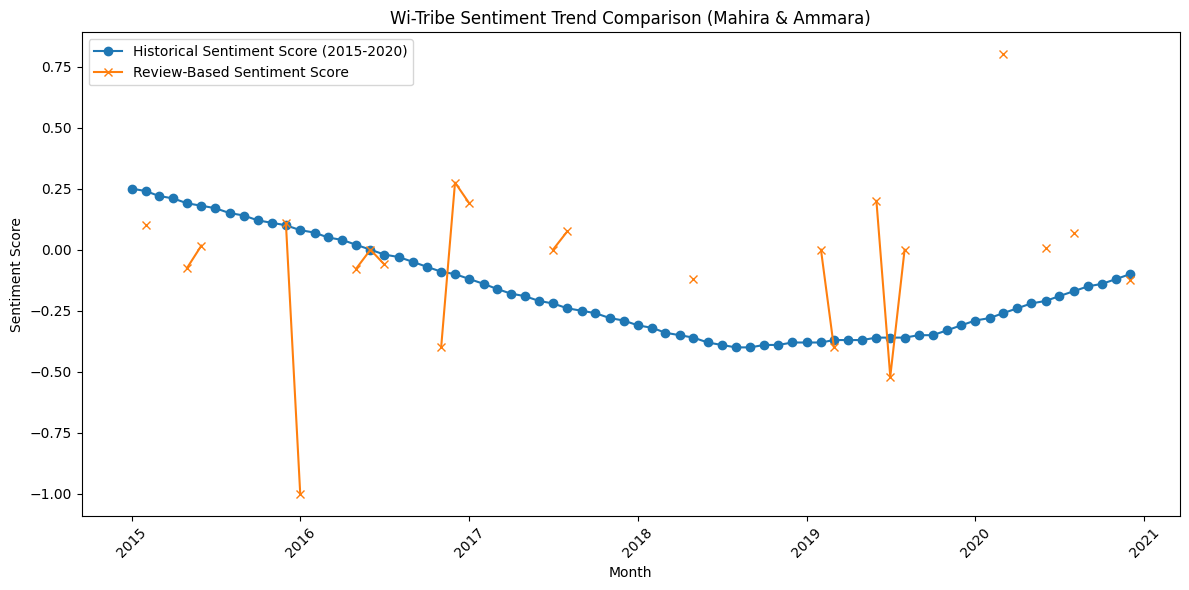


Sentiment Comparison Table:

        Month  Sentiment_Score_Historical  Sentiment_Score_FromReviews  \
62 2020-03-01                       -0.26                     0.800000   
63 2020-04-01                       -0.24                          NaN   
64 2020-05-01                       -0.22                          NaN   
65 2020-06-01                       -0.21                     0.007143   
66 2020-07-01                       -0.19                          NaN   
67 2020-08-01                       -0.17                     0.068182   
68 2020-09-01                       -0.15                          NaN   
69 2020-10-01                       -0.14                          NaN   
70 2020-11-01                       -0.12                          NaN   
71 2020-12-01                       -0.10                    -0.125000   

   Sentiment_Label  
62        Positive  
63             NaN  
64             NaN  
65         Neutral  
66             NaN  
67        Positive  
68      

In [9]:
# --- Mahira & Ammara Task: Wi-Tribe Sentiment + Performance Analysis ---

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

# Step 2: Load the Datasets
reviews = pd.read_csv(r"C:\Brand Management\wi_tribe_reviews_simulated.csv")
sentiment_trend = pd.read_csv(r"C:\Brand Management\WiTribe_Sentiment_Output_2015_2020.csv")

# Step 3: Convert Date Columns to Datetime
reviews['Date'] = pd.to_datetime(reviews['Date'])
sentiment_trend['Month'] = pd.to_datetime(sentiment_trend['Month'])

# Step 4: Perform Sentiment Analysis on Reviews
def get_sentiment(text):
    analysis = TextBlob(str(text))
    return analysis.sentiment.polarity

reviews['Sentiment_Score'] = reviews['Review Text'].apply(get_sentiment)

# Step 5: Label Each Review as Positive / Negative / Neutral
def label_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews['Sentiment_Label'] = reviews['Sentiment_Score'].apply(label_sentiment)

# Step 6: Aggregate Review Sentiments Monthly
reviews['Month'] = reviews['Date'].dt.to_period('M').dt.to_timestamp()

monthly_reviews = (
    reviews.groupby('Month', as_index=False)
    .agg({
        'Sentiment_Score': 'mean',
        'Sentiment_Label': lambda x: x.value_counts().index[0]  # Most frequent label
    })
)

# Step 7: Merge Monthly Reviews with Historical Sentiment Trend
merged = sentiment_trend.merge(monthly_reviews, on='Month', how='outer', suffixes=('_Historical', '_FromReviews'))
merged.sort_values('Month', inplace=True)
merged.reset_index(drop=True, inplace=True)

# Step 8: Visualization - Sentiment Comparison
plt.figure(figsize=(12,6))
plt.plot(merged['Month'], merged['Sentiment_Score_Historical'], label='Historical Sentiment Score (2015-2020)', marker='o')
plt.plot(merged['Month'], merged['Sentiment_Score_FromReviews'], label='Review-Based Sentiment Score', marker='x')
plt.title('Wi-Tribe Sentiment Trend Comparison (Mahira & Ammara)')
plt.xlabel('Month')
plt.ylabel('Sentiment Score')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 9: Summary Table
print("\nSentiment Comparison Table:\n")
print(merged[['Month', 'Sentiment_Score_Historical', 'Sentiment_Score_FromReviews', 'Sentiment_Label']].tail(10))

# Step 10: Insights / Interpretation
print("""
--- Insights / Interpretation ---

1. The review-based sentiment shows how customers currently feel about Wi-Tribe (based on actual review text).
2. The historical sentiment trend (2015–2020) represents the overall brand perception over time.
3. If both trends move together (positive or negative), it means customer perception is stable and consistent.
4. If current reviews are more negative than historical sentiment, it suggests new dissatisfaction issues.
5. If current reviews are more positive, it indicates improvement in service quality or brand reputation.
""")
